# NxM grid world Markov Decision Process

Let's try to understand and build states, actions, reward functions, and transition probabilities for a NxM grid world. In the next section, we will implement a frozenLakeEnvironment from scratch by following OOP concepts to make it more scalable and managable, but for now let's focus on the core part of the implement of MDP in a grid world.

The MDP will be defined as the following global variable or function:
  - $S$ is a finite set of states
  - $A$ is a finite set of actions
  - $P$ is a state transition probability matrix
  - $R$ is a reward function,
     - $R_s = E[R_{t+1} | S_t=s, A_t=a]$

Let's consider a 3x3 grid world for this section

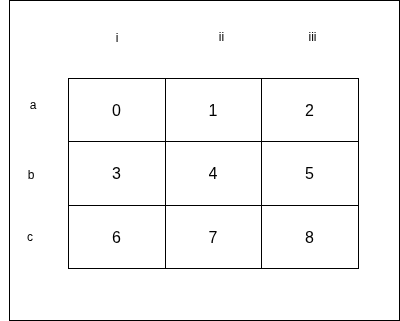

# State 📍

In nXm grid world, the state can be represented in multiple ways. 
- A state could be 2D representation $(r, c)$, where r is the row index and c is the column index. For instance, (a, i), (a, iii)
- A state could be 1D flatten index representation of 2D grid. In the above 3X3 grid world, we will have [0, 1, 2, 3, 4, 5, 6, 7, 8] states in total.
- A state could be one-hot representation of 1D representation. For instance, state s=1 could be represented as [1, 0, 0, 0, 0, 0, 0, 0, 0]; similarly, s=5 could be represented as [0, 0, 0 ,0, 1, 0, 0, 0, 0].
- A state could be represented with some other rule, for instance, a one-hot representation of a wall it touches [1, 1, 0, 0].
- A state could be represented in a more complex way too, like a one-dimensional feature extracted from a CNN feature extractor layer where the input is an image of an agent in a specific position.

- State could be represented in any possible way, but make sure there isn't any ambiguity, and we should be able to encode and decode it easily. 

One of the simplest ways is to represent it in 1D indices, so from now on we are going to represent it in such a way.
Defining functions to convert 2D (r,c) index to 1D represent and vice-versa.

In [5]:
# convert (r, c) to 1D index
def get_1d_representation(r, c, num_cols):
    return r*num_cols+c

In [2]:
get_1d_representation(0, 0, 3)

0

In [3]:
get_1d_representation(1, 1, 3)

4

In [6]:
# convert 1D index to (r, c)
def get_2d_representation(idx, num_cols):
    r = idx // num_cols
    c = idx % num_cols
    return (r, c)

In [7]:
get_2d_representation(0, 3)

(0, 0)

In [8]:
get_2d_representation(4, 3)

(1, 1)

# Action 🚶

In our nXm grid environment, the possible actions are:
- the agent can move to `left` valid state
- the agent can move to `right` valid state
- the agent can move to `up` valid state
- the agent can move to `down` valid state
- the agent cannot move to a diagonal state.
- The agent is not allowed to move outside the boundary; if it tries, it should be back to the same state.

In [41]:
ALLOWED_ACTIONS = {
                   "left":  0,
                   "down": 1,
                   "right": 2,
                   "up": 3
            }

INV_ALLOWED_ACTIONS = {v:k for k, v in ALLOWED_ACTIONS.items()}

ACTION_STEPS = {
             0: (0, -1), # left step:  means staying in the same row (row unchanged), moving one column left from the current cell i.e -1
             1: (1, 0), # down step: means moving to the next row (+1 row) but staying in the same column
             2: (0, 1), # right step: means staying in the same row (row unchanged), moving to the subsequent right column i.e +1
             3: (-1, 0) # up: step means staying in the same column but moving one row up i.e -1 
        }

In [15]:
def move(state_idx, action, num_rows, num_cols):
    # decode state and action
    r, c = get_2d_representation(state_idx, num_cols)
    action_idx = ALLOWED_ACTIONS[action]
    # --------
    
    step_r, step_c = ACTION_STEPS[action_idx]
    new_r = min(max(0, r+step_r), num_rows -1) #make sure step is a valid one
    new_c = min(max(0, c+step_c), num_cols -1)
    return new_r, new_c

In [17]:
# move left from state 4 i.e (1, 1) -to-> (1, 0)
move(4, "left", 3, 3)

(1, 0)

In [18]:
# move right from state 4 i.e (1, 1) -to-> (1, 2)
move(4, "right", 3, 3)

(1, 2)

In [19]:
# move right from state 4 i.e (1, 1) -to-> (0, 1)
move(4, "up", 3, 3)

(0, 1)

In [20]:
# move right from state 4 i.e (1, 1) -to-> (2, 1)
move(4, "down", 3, 3)

(2, 1)

In [21]:
# invalid move --> agent stays at the same state
move(0, "left", 3, 3) 

(0, 0)

# REWARD 🏆

> $R$ is a reward function, $R_s = E[R_{t+1} | S_t=s, A_t=a]$
- For our grid world, we are going to set the reward as a deterministic model, meaning the agent will get the predetermined reward after reaching the state $S$ with probability 1.0.
- Note that reward can also be stochastic, and different state-action-new_state $S-A-S'$ can be different rewards.
- For the sake of simplicity, we are going to model reward as a look-up table.
  - Let's categorize each state in one of three categories.
      - N: normal state
      - D: danger state
      - G: target state
- If the agent reaches to the state `N` it will get  reward point `0`, similary `D` state might have reward of `-1` and `G` has 100.

In [46]:
reward_points = {
    "N": 0,
    "D": -1,
    "G": 100
}

In [49]:
def get_reward(state_idx):
    # we have hardcorded the state category, in upcomming notebooks 
    # we will give nave to the grid cells so no need to grouped state like this
    state_groups = {
        "N": [0, 1, 2, 3],
        "D": [4, 7],
        "G": [8]
    }
    state_category = "N"
    for k, v in state_groups.items():
        if state_idx in v:
            state_category = k
            break
    return reward_points[k]

In [53]:
get_reward(0) # normal state

0

In [51]:
get_reward(8) #goal state

100

In [52]:
get_reward(4) #danger state

-1

# Transition Probability 🎲

> For a Markov state $S$ and successor state $S'$, the state transition probability is
  $P_{SS'}$ = P[ $S_{t+1}$ = $S'$ | $S_t$ = S ]

- Before defining a transition probability matrix, let's understand deterministic and stochastic transition behaviour.
- **Deterministic environment:**
    - In our grid world, if the agent tries to move `left` from state 4, it will reach state 5 with probability 100%. So in the deterministic environment, the agent will reach the intended next state $S'$ for the current state $S$ if the action $A$ is valid; otherwise, the agent will stay at the same state $S$.
- **Stochastic environment**:
   - Let's say this grid world is slippery, so if the agent tries to move to the left, then there is a probability that the agent will move to the other directions also (the agent slips).
   - If the agent tries to move `left` from state 4, it will reach state 5 with probability $P1 < 1.0$ and move to state 1, 7 and 3 with certain probability $P2$ where $0 < p2 < P1$.

Let’s define a transition probability function that takes the current state index and an action as input, and returns a list of possible next states along with the reward and the probability of reaching each state after taking that action.

In [54]:
def get_transition_probability(state_idx, action, num_rows, num_cols, slippery=False):
    env_dynamics = {
        "intended_action": 0.7, # 70% chance that the agent will perform the intended action
        "other_action": 0.1, # 10% chance that each remaining action will be performed 
    }

    action_idx = ALLOWED_ACTIONS[action]
    r, c = get_2d_representation(state_idx, num_cols)
    
    if slippery == False: # deterministic environment
        action_probs = {action_idx: 1.0}

    else:
        action_probs = {
            action_idx : env_dynamics["intended_action"],
            # remaining actions
            action_idx + 1 % len(ALLOWED_ACTIONS) : env_dynamics["other_action"],
            action_idx + 2 % len(ALLOWED_ACTIONS) : env_dynamics["other_action"],
            action_idx + 3 % len(ALLOWED_ACTIONS) : env_dynamics["other_action"]
        }

    trans_prob = []
    for action_idx, action_prob in action_probs.items():
        action = INV_ALLOWED_ACTIONS[action_idx]
        new_r, new_c = move(state_idx, action, num_rows, num_cols)
        new_state_idx = get_1d_representation(new_r, new_c, num_cols)
        reward = get_reward(new_state_idx)
        trans_prob.append(
            {
                "new_state": new_state_idx,
                "probs": action_prob,
                "reward": reward
            }
        )

    return trans_prob

In [55]:
# since environment is deterministic, the agent will reach to state 1 with prob 1.0 after move left from state 0
get_transition_probability(0, "right", 3, 3, slippery=False)

[{'new_state': 1, 'probs': 1.0, 'reward': 0}]

In [56]:
# invalid action, so agent should remain the same state 0.
get_transition_probability(0, "left", 3, 3, slippery=False)

[{'new_state': 0, 'probs': 1.0, 'reward': 0}]

In [58]:
# probability of moving to new_state 3, 7, 5, 1 from state 4 after taking "left" action
get_transition_probability(4, "left", 3, 3, slippery=True)

[{'new_state': 3, 'probs': 0.7, 'reward': 0},
 {'new_state': 7, 'probs': 0.1, 'reward': -1},
 {'new_state': 5, 'probs': 0.1, 'reward': 100},
 {'new_state': 1, 'probs': 0.1, 'reward': 0}]

# conclusion
We have successfully 🎉 constructed the nXm grid world as a Markov Decision Process (MDP). Please note that this implementation is a simplified version of how an MDP environment can be constructed. In subsequent lessons, we will focus more on scalability and engineering design principles while representing the environment and implementing the RL algorithm, ensuring that everything remains modular without introducing any unnecessary complexity.